In [1]:
import numpy as np
from numpy import linalg, random
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image

In [ ]:
A = random.randint(1, 30, size=(5, 5))
linalg.inv(linalg.inv(A)), A

(array([[ 4., 18., 24.,  8.,  2.],
        [25.,  1.,  7.,  6., 23.],
        [27.,  2., 14., 18., 25.],
        [16., 16., 10.,  3., 21.],
        [12.,  2., 21., 19., 15.]]),
 array([[ 4, 18, 24,  8,  2],
        [25,  1,  7,  6, 23],
        [27,  2, 14, 18, 25],
        [16, 16, 10,  3, 21],
        [12,  2, 21, 19, 15]]))

In [83]:
colors = make_subplots(2, 3, column_widths=[0.2, 0.2, 0.2])

random.seed(0)
A = random.randint(1, 10, size=(6, 6))
colors.add_trace(go.Heatmap(z=A, colorscale='gray'), row=1, col=1)


A_transform = A.copy()
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        A_transform[i, j] = np.round(linalg.det(np.delete(np.delete(A, i, axis=0), j, axis=1)))
colors.add_trace(go.Heatmap(z=A_transform, colorscale='gray'), row=1, col=2)

grid = (-1) ** (np.arange(A_transform.shape[0])[:, np.newaxis] + np.arange(A_transform.shape[1]))
colors.add_trace(go.Heatmap(z=grid, colorscale='gray'), row=1, col=3)

A_transform *= grid
colors.add_trace(go.Heatmap(z=A_transform, colorscale='gray'), row=2, col=1)

A_inv = (linalg.det(A) ** -1) * A_transform.T 
colors.add_trace(go.Heatmap(z=A_inv, colorscale='gray'), row=2, col=2)

res = A_inv @ A
colors.add_trace(go.Heatmap(z=res, colorscale='gray'), row=2, col=3)

colors.show()


In [99]:
width =random.randint(1, 50, size=(3, 20))

A = width @ width.T
obr = linalg.inv(A) @ width
obr @ width.T

array([[ 1.00000000e+00, -8.81239526e-16, -6.10622664e-16],
       [ 4.91794105e-16,  1.00000000e+00,  2.58473798e-16],
       [-2.18575158e-16, -2.63677968e-16,  1.00000000e+00]])

In [104]:
A = random.randint(1, 40, size=(3, 3))
A @ linalg.pinv(A)

array([[ 1.00000000e+00, -4.24660307e-15, -2.51881849e-15],
       [ 4.96824804e-15,  1.00000000e+00, -2.07472928e-15],
       [ 4.94049246e-15, -3.27515792e-15,  1.00000000e+00]])

In [ ]:
A = random.randint(1, 100, size=(3, 3))
B = random.randint(1, 100, size=(3, 3))

res1 = linalg.inv(A @ B)
res2 = linalg.inv(A) @ linalg.inv(B)
res3 = linalg.inv(B) @ linalg.inv(A)

print(np.sum((res1-res2)**2))
print(np.sum((res1-res3)**2))
print(np.sum((res2-res3)**2))

1.4223115361173442e-06
5.442538844307191e-36
1.4223115361173404e-06


(array([[ 1, 96, 57],
        [71, 83, 87],
        [63, 47, 90]]),
 array([[78, 13, 63],
        [38, 84, 32],
        [29, 60, 84]]))

In [ ]:
T = random.randint(1, 20, size=(10, 4))
TtT = linalg.inv(T.T @ T)
TtTT = T.T @ linalg.pinv(T) # нельзя так епта

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 10)

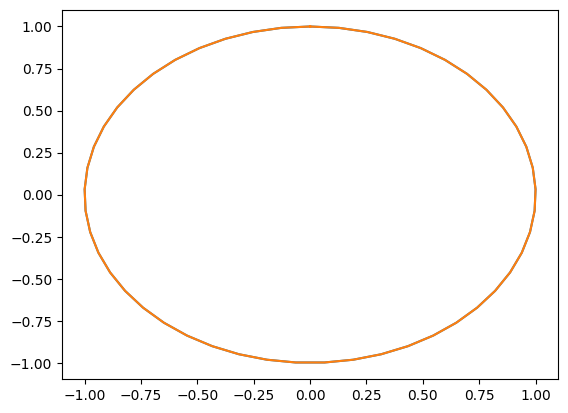

In [130]:
import matplotlib.pyplot as plt


osc_x = np.sin(np.linspace(0, 2*np.pi, 50))
osc_y = np.cos(np.linspace(0, 2*np.pi, 50))
for_tr = np.vstack((osc_x, osc_y))
plt.plot(osc_x, osc_y)

tr = np.array([
    [1, 0.2],
    [0, 0.5]
])

res = tr @ for_tr
ress = linalg.inv(tr)
res = ress @ res
plt.plot(res[0], res[1])
plt.show()


In [157]:
import scipy.linalg as lng

def gilbert(g):
    x, y = np.meshgrid(np.arange(1, g+1), np.arange(1, g+1))
    return (np.float64(x + y -1)) ** (-1)

gilbert(5) == lng.hilbert(5)

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])

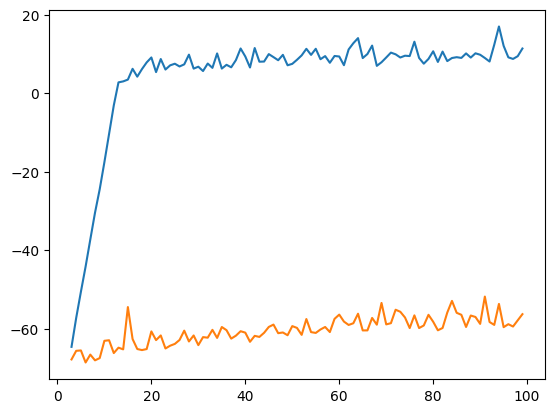

In [ ]:
hilb_result = np.array([])
cond_result = np.array([])
rand_result = np.array([])
rand_cond_result = np.array([])

for n in range(3, 100):
    gilb = lng.hilbert(n)
    dist1 = gilb @ linalg.inv(gilb)
    res1 = np.sum((dist1 - np.eye(n))**2)
    rand_a = random.randint(1, 50, size=(n, n))
    dist2 = rand_a @ linalg.inv(rand_a)
    res2 = np.sum((dist2 - np.eye(n))**2)
    
    hilb_result = np.append(hilb_result, res1)
    cond_result = np.append(cond_result, linalg.cond(dist1))
    rand_result = np.append(rand_result, res2)
    rand_cond_result = np.append(rand_cond_result, linalg.cond(dist2))

plt.plot(np.arange(3, 100), np.log(hilb_result))
plt.plot(np.arange(3, 100), np.log(rand_result))
plt.show()